In [1]:
import numpy as np
import pandas as pd
import math
import warnings

from pathlib import Path
from scipy.stats import norm

from sklearn import svm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, ConstantKernel as C
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA

# plotting
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions
from mpl_toolkits.mplot3d import Axes3D

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


# Helper Functions

In [2]:
def compute_ucb(mu, sigma, kappa=2.5):
    """Compute Upper Confidence Bound acquisition function"""
    return mu + kappa * sigma

def compute_ei(mu, sigma, f_best, xi=0.01):
    """Compute Expected Improvement acquisition function"""
    z = (mu - f_best - xi) / (sigma + 1e-9)
    ei = (mu - f_best - xi) * norm.cdf(z) + sigma * norm.pdf(z)
    ei[sigma == 0] = 0
    return ei

def format_query(point, decimals=6):
    """Format point for portal submission"""
    point_clipped = np.clip(point, 0, 0.999999)
    return '-'.join([f'{x:.{decimals}f}' for x in point_clipped])

def analyze_improvement(outputs):
    """Analyze if last query improved over previous best"""
    if len(outputs) < 2:
        return None, None
    last_output = outputs[-1]
    previous_best = outputs[:-1].max()
    improvement = last_output - previous_best
    return improvement, last_output >= previous_best

# Function 1: Radiation Detection (2D) 
### Using: Logistic Regression (sparse signals) and Linear Regression (direction within signal regions)

In [4]:
print("\n")
print("F1 (2D) - Radiation Detection")
print("Hybrid: Logistic (find hotspots) + Linear (direction within hotspots)")

# Load Week 1 data
inputs = np.load('/Users/odes_to_knavery/Documents/AI_ML/Captone/bbo_data/function_1/initial_inputs.npy')
outputs = np.load('/Users/odes_to_knavery/Documents/AI_ML/Captone/bbo_data/function_1/initial_outputs.npy')

# Add Week 1 result
week1_query = np.array([[0.959184, 0.836735]])
week1_output = np.array([-5.909566597235814e-107])

all_inputs = np.vstack([inputs, week1_query])
all_outputs = np.hstack([outputs, week1_output])

print(f"Data: {all_inputs.shape[0]} points")
print(f"Output range: [{all_outputs.min():.2e}, {all_outputs.max():.2e}]")
print(f"Current best: {all_outputs.max():.2e}")

# Linear Regression: Direction Analysis  
lr = LinearRegression()
lr.fit(all_inputs, all_outputs)

print(f"\nLinear Regression Insights:")
print(f"  Coefficients: x1={lr.coef_[0]:+.4f}, x2={lr.coef_[1]:+.4f}")

# Logistic Regression: Signal Classification  
threshold = -0.001
y_binary = (all_outputs > threshold).astype(int)

print(f"\nLogistic Regression Classification:")
print(f"  Threshold: {threshold}")
print(f"  Signal points: {y_binary.sum()}/{len(y_binary)}")

if len(np.unique(y_binary)) == 2:
    log_reg = LogisticRegression(random_state=42)
    log_reg.fit(all_inputs, y_binary)
    print(f"  Classification coefficients: {log_reg.coef_[0]}")
    print(f"Identifies regions likely to have signal")
    use_logistic = True
else:
    print(f"Insufficient class diversity for logistic regression")
    use_logistic = False

# Gaussian Process  
kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=0.15, nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=20, alpha=1e-6, normalize_y=True)
gp.fit(all_inputs, all_outputs)

# Candidate Generation   
np.random.seed(42)

# random exploration (sparse function needs exploration)
random_candidates = np.random.uniform(0, 1, (6000, 2))

# near signal points (use logistic classification)
signal_candidates = []
signal_indices = np.where(y_binary == 1)[0]

for index in signal_indices:
    n_per_signal = int(4000 / len(signal_indices))
    for _ in range(n_per_signal):
        # small offset added to signal points
        random_offset = np.random.normal(0, 0.1, 2)
        candidate = np.clip(all_inputs[index] + random_offset, 0, 1)
        signal_candidates.append(candidate)

candidates = np.vstack([random_candidates, signal_candidates])

# Acquisition Function   
# Switched from UCB to EI (based on Week 1 performance)
mu, sigma = gp.predict(candidates, return_std=True)
ei = compute_ei(mu, sigma, all_outputs.max(), xi=0.05)  # Moderate exploration

# Select best
best_index = np.argmax(ei)
query = candidates[best_index]

print(f"\nWeek 2 Query: {format_query(query)}")
print(f"mean: {mu[best_index]:.2e}, \nstandard deviation: {sigma[best_index]:.2e}")
print(f"EI: {ei[best_index]:.6f}")



F1 (2D) - Radiation Detection
Hybrid: Logistic (find hotspots) + Linear (direction within hotspots)
Data: 11 points
Output range: [-3.61e-03, 7.71e-16]
Current best: 7.71e-16

Linear Regression Insights:
  Coefficients: x1=-0.0001, x2=-0.0004

Logistic Regression Classification:
  Threshold: -0.001
  Signal points: 10/11
  Classification coefficients: [-0.05770016 -0.10607285]
Identifies regions likely to have signal

Week 2 Query: 0.374540-0.950714
mean: -3.28e-04, 
standard deviation: 1.04e-03
EI: 0.000000


/Users/odes_to_knavery/Library/Python/3.9/lib/python/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


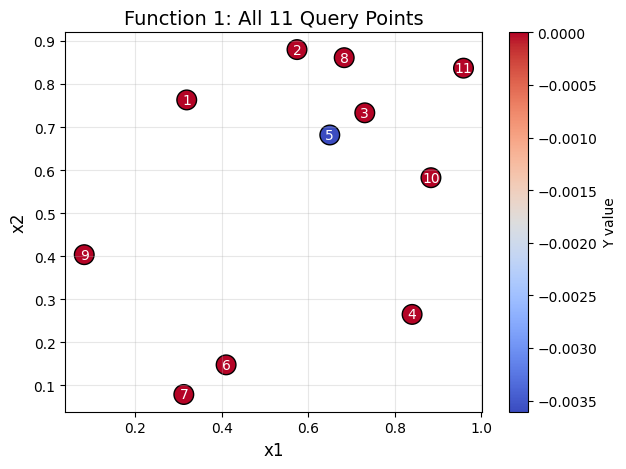

Total points: 11
Point 1: X=[0.319, 0.763], Y=1.322677e-79
Point 2: X=[0.574, 0.880], Y=1.033078e-46
Point 3: X=[0.731, 0.733], Y=7.710875e-16
Point 4: X=[0.840, 0.265], Y=3.341771e-124
Point 5: X=[0.650, 0.682], Y=-3.606063e-03
Point 6: X=[0.410, 0.148], Y=-2.159249e-54
Point 7: X=[0.313, 0.079], Y=-2.089093e-91
Point 8: X=[0.683, 0.861], Y=2.535001e-40
Point 9: X=[0.083, 0.403], Y=3.606771e-81
Point 10: X=[0.884, 0.582], Y=6.229856e-48
Point 11: X=[0.959, 0.837], Y=-5.909567e-107


In [5]:
# Plot function 1 data
plt.title(f'Function 1: All {len(all_inputs)} Query Points', fontsize=14)

scatter = plt.scatter(all_inputs[:, 0], all_inputs[:, 1], c=all_outputs, s=200, cmap='coolwarm', edgecolors='black', linewidth=1)
plt.colorbar(scatter, label='Y value')

# Add point numbers
for i in range(len(all_inputs)):
    plt.text(all_inputs[i, 0], all_inputs[i, 1], str(i+1), fontsize=10, 
            ha='center', va='center', color='white', weight='normal')

plt.xlabel('x1', fontsize=12)
plt.ylabel('x2', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print the values
print(f"Total points: {len(all_inputs)}")
for i in range(len(all_inputs)):
    print(f"Point {i+1}: X=[{all_inputs[i,0]:.3f}, {all_inputs[i,1]:.3f}], Y={all_outputs[i]:.6e}")

# FUNCTION 2: Noisy Log-Likelihood (2D)
### Using: Logistic Regression (good vs bad basin) and Linear Regression (local gradient)

In [6]:
print("\n")
print("F2 (2D) - Noisy Log-Likelihood")
print("Hybrid: Logistic (basin classification) + Linear (local gradient)")


inputs = np.load('/Users/odes_to_knavery/Documents/AI_ML/Captone/bbo_data/function_2/initial_inputs.npy')
outputs = np.load('/Users/odes_to_knavery/Documents/AI_ML/Captone/bbo_data/function_2/initial_outputs.npy')

week1_query = np.array([[0.775510, 0.959184]])
week1_output = np.array([0.16576674010067213])

all_inputs = np.vstack([inputs, week1_query])
all_outputs = np.hstack([outputs, week1_output])

print(f"Data: {all_inputs.shape[0]} points")
print(f"Output range: [{all_outputs.min():.3f}, {all_outputs.max():.3f}]")
print(f"Current best: {all_outputs.max():.3f}")

# Linear Regression: Local Gradient  
lr = LinearRegression()
lr.fit(all_inputs, all_outputs)

print("\nLinear Regression:")
print(f"  Coefficients: x1={lr.coef_[0]:+.4f}, x2={lr.coef_[1]:+.4f}")

# Logistic Regression 
threshold = 0.3 
y_binary = (all_outputs > threshold).astype(int)
print("\nLogistic Regression:")
print(f"  Threshold: {threshold}")
print(f"  Points above threshold: {y_binary.sum()}/{len(y_binary)}")

if len(np.unique(y_binary)) == 2:
    log_reg = LogisticRegression(random_state=42)
    log_reg.fit(all_inputs, y_binary)
    use_logistic = True
else:
    print(f"All points in same class, need more exploration")
    use_logistic = False

# Gaussian Process  
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=20, alpha=0.01, normalize_y=True)
gp.fit(all_inputs, all_outputs)

# Candidate Generation (HYBRID)  
np.random.seed(42)

# random exploration (need to find new basins)
random_candidates = np.random.uniform(0, 1, (7000, 2))

# near best points (local refinement)
near_best = []
top3_idx = np.argsort(all_outputs)[-3:]
for index in top3_idx:
    for _ in range(1000):
        random_offset = np.random.normal(0, 0.1, 2)
        candidate = np.clip(all_inputs[index] + random_offset, 0, 1)
        near_best.append(candidate)

candidates = np.vstack([random_candidates, near_best])

# Acquisition Function  
mu, sigma = gp.predict(candidates, return_std=True)
ei = compute_ei(mu, sigma, all_outputs.max(), xi=0.1)  # High exploration

best_index = np.argmax(ei)
query = candidates[best_index]

print(f"\nWeek 2 Query: {format_query(query)}")
print(f"mean: {mu[best_index]:.3f} \nstandard deviation: {sigma[best_index]:.3f}")
print(f"EI: {ei[best_index]:.6f}")



F2 (2D) - Noisy Log-Likelihood
Hybrid: Logistic (basin classification) + Linear (local gradient)
Data: 11 points
Output range: [-0.066, 0.611]
Current best: 0.611

Linear Regression:
  Coefficients: x1=+0.7817, x2=-0.1362

Logistic Regression:
  Threshold: 0.3
  Points above threshold: 3/11

Week 2 Query: 0.683114-0.932567
mean: 0.491 
standard deviation: 0.155
EI: 0.005416


# FUNCTION 3: Drug Discovery (3D)
### Using: Linear Regression (gradient direction) and Logistic Regression (low vs high adverse reactions)

In [7]:
print("\n")
print("F3 (3D) - Drug Discovery")
print("Hybrid: Linear (gradient) + Logistic (safety classification)")


inputs = np.load('/Users/odes_to_knavery/Documents/AI_ML/Captone/bbo_data/function_3/initial_inputs.npy')
outputs = np.load('/Users/odes_to_knavery/Documents/AI_ML/Captone/bbo_data/function_3/initial_outputs.npy')

week1_query = np.array([[0.378956, 0.302768, 0.459346]])
week1_output = np.array([-0.02906213067759293])

all_inputs = np.vstack([inputs, week1_query])
all_outputs = np.hstack([outputs, week1_output])

print(f"Data: {all_inputs.shape[0]} points")
print(f"Output range: [{all_outputs.min():.4f}, {all_outputs.max():.4f}]")
print(f"Current best: {all_outputs.max():.4f}")

# Linear Regression: Gradient Direction  
lr = LinearRegression()
lr.fit(all_inputs, all_outputs)

print("\nLinear Regression:")
print(f"  Intercept: {lr.intercept_:.2f}")
for i, coef in enumerate(lr.coef_):
    print(f"  x{i+1}: {coef:.2f}")

# Logistic Regression: Safety Classification  
threshold = -0.1  # Low adverse reactions
y_binary = (all_outputs > threshold).astype(int)

print("\nLogistic Regression:")
print(f"  Threshold: {threshold}")
print(f"  Above threshold: {y_binary.sum()}/{len(y_binary)}")

if len(np.unique(y_binary)) == 2:
    log_reg = LogisticRegression(random_state=42)
    log_reg.fit(all_inputs, y_binary)

# Candidate Generation   
np.random.seed(42)

# gradient-biased (follow linear regression direction)
gradient_biased = np.zeros((5000, 3))
for dim in range(3):
    if lr.coef_[dim] > 0:
        # Positive coefficient  to  sample toward higher values
        gradient_biased[:, dim] = np.random.uniform(0.3, 1.0, 5000)
    else:
        # Negative coefficient  to  sample toward lower values
        gradient_biased[:, dim] = np.random.uniform(0.0, 0.7, 5000)

# near best points (exploitation)
near_best = []
top5_indexes = np.argsort(all_outputs)[-5:]
for index in top5_indexes:
    for _ in range(200):
        random_offset = np.random.normal(0, 0.05, 3)
        candidate = np.clip(all_inputs[index] + random_offset, 0, 1)
        near_best.append(candidate)

candidates = np.vstack([gradient_biased, near_best])

# Gaussian Process  
kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=0.5, nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=20, alpha=1e-6, normalize_y=True)
gp.fit(all_inputs, all_outputs)

# Acquisition Function   
mu, sigma = gp.predict(candidates, return_std=True)
ei = compute_ei(mu, sigma, all_outputs.max(), xi=0.001)  # Tight exploitation

best_index = np.argmax(ei)
query = candidates[best_index]

print(f"\nWeek 2 Query: {format_query(query)}")
print(f"mean: {mu[best_index]:.4f}, \nstandard deviation: {sigma[best_index]:.4f}")
print(f"EI: {ei[best_index]:.6f}")



F3 (3D) - Drug Discovery
Hybrid: Linear (gradient) + Logistic (safety classification)
Data: 16 points
Output range: [-0.3989, -0.0291]
Current best: -0.0291

Linear Regression:
  Intercept: -0.03
  x1: 0.07
  x2: -0.06
  x3: -0.18

Logistic Regression:
  Threshold: -0.1
  Above threshold: 8/16

Week 2 Query: 0.315339-0.088659-0.415174
mean: -0.0489, 
standard deviation: 0.0681
EI: 0.018011


# FUNCTION 4: Warehouse Placement (4D)
### Using: Linear Regression (feature importance) and Logistic Regression (good vs poor performance)

In [8]:
print("\n")
print("F4 (4D) - Warehouse Placement")
print("Hybrid: Linear (feature importance) + Logistic (performance classification)")


inputs = np.load('/Users/odes_to_knavery/Documents/AI_ML/Captone/bbo_data/function_4/initial_inputs.npy')
outputs = np.load('/Users/odes_to_knavery/Documents/AI_ML/Captone/bbo_data/function_4/initial_outputs.npy')

week1_query = np.array([[0.466173, 0.451984, 0.359193, 0.383111]])
week1_output = np.array([-0.9654345395220925])

all_inputs = np.vstack([inputs, week1_query])
all_outputs = np.hstack([outputs, week1_output])

print(f"Data: {all_inputs.shape[0]} points")
print(f"Output range: [{all_outputs.min():.2f}, {all_outputs.max():.2f}]")
print(f"Current best: {all_outputs.max():.2f}")

# Linear Regression: Feature Importance  
lr = LinearRegression()
lr.fit(all_inputs, all_outputs)

print("\nLinear Regression - Coefficients ranked:")
feature_importance = [(i, coef, abs(coef)) for i, coef in enumerate(lr.coef_)]
feature_importance.sort(key=lambda x: x[2], reverse=True)
for rank, (dim, coef, abs_coef) in enumerate(feature_importance, 1):
    print(f"  {rank}. x{dim+1}: {coef:.3f}")


# Logistic Regression: Performance Classification  
threshold = -10.0  
y_binary = (all_outputs > threshold).astype(int)

print(f"\nLogistic Regression:")
print(f"  Threshold: {threshold}")
print(f"  Above threshold: {y_binary.sum()}/{len(y_binary)}")

if len(np.unique(y_binary)) == 2:
    log_reg = LogisticRegression(random_state=42)
    log_reg.fit(all_inputs, y_binary)

# Candidate Generation   
np.random.seed(42)

# tight local search around Week 1 success
local_search = []
for _ in range(7000):
    random_offset = np.random.normal(0, 0.03, 4)
    candidate = np.clip(week1_query[0] + random_offset, 0, 1)
    local_search.append(candidate)

# feature-weighted exploration (vary important features more)
feature_weighted = []
for _ in range(3000):
    candidate = week1_query[0].copy()
    for dim, coef, abs_coef in feature_importance[:2]:  # Top 2 features
        # Vary important features more
        candidate[dim] += np.random.normal(0, 0.1)
    candidate = np.clip(candidate, 0, 1)
    feature_weighted.append(candidate)

candidates = np.vstack([local_search, feature_weighted])

# Gaussian Process  
kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=0.3, nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=20, alpha=1e-6, normalize_y=True)
gp.fit(all_inputs, all_outputs)

# Acquisition Function   
mu, sigma = gp.predict(candidates, return_std=True)
ei = compute_ei(mu, sigma, all_outputs.max(), xi=0.01)  # Balanced

best_index = np.argmax(ei)
query = candidates[best_index]

print(f"\nWeek 2 Query: {format_query(query)}")
print(f"mean: {mu[best_index]:.3f} \nstandard deviation: {sigma[best_index]:.3f}")
print(f"EI: {ei[best_index]:.6f}")



F4 (4D) - Warehouse Placement
Hybrid: Linear (feature importance) + Logistic (performance classification)
Data: 31 points
Output range: [-32.63, -0.97]
Current best: -0.97

Linear Regression - Coefficients ranked:
  1. x4: -10.741
  2. x1: -8.822
  3. x2: -7.534
  4. x3: -3.140

Logistic Regression:
  Threshold: -10.0
  Above threshold: 4/31

Week 2 Query: 0.424201-0.406375-0.372722-0.413313
mean: -0.739 
standard deviation: 0.264
EI: 0.246872


# FUNCTION 5: Chemical Yield (4D)
### Using: Linear Regression (direction to peak) and Logistic Regression (high vs low yield)

In [9]:
print("\n")
print("F5 (4D) - Chemical Yield")
print("Hybrid: Linear (direction) + Logistic (yield classification)")


inputs = np.load('/Users/odes_to_knavery/Documents/AI_ML/Captone/bbo_data/function_5/initial_inputs.npy')
outputs = np.load('/Users/odes_to_knavery/Documents/AI_ML/Captone/bbo_data/function_5/initial_outputs.npy')

week1_query = np.array([[0.284290, 0.869208, 0.999999, 0.903273]])
week1_output = np.array([2201.834589108927])

all_inputs = np.vstack([inputs, week1_query])
all_outputs = np.hstack([outputs, week1_output])

print(f"Data: {all_inputs.shape[0]} points")
print(f"Output range: [{all_outputs.min():.2f}, {all_outputs.max():.2f}]")
print(f"Current best: {all_outputs.max():.2f}")

# Linear Regression: Chemical Input Effects  
lr = LinearRegression()
lr.fit(all_inputs, all_outputs)

print(f"\nLinear Regression (Chemical Input Analysis):")
print(f"Intercept: {lr.intercept_:.2f}")
print("Coefficients:")
for i, coef in enumerate(lr.coef_):
    print(f"    x{i+1}: {coef:.2f}")

# Logistic Regression: Yield Classification  
threshold = 500  # High threshold
y_binary = (all_outputs > threshold).astype(int)

print(f"\nLogistic Regression (Yield Classification):")
print(f"  Threshold: {threshold} (high yield)")
print(f"  High yield points: {y_binary.sum()}/{len(y_binary)}")

if len(np.unique(y_binary)) == 2:
    log_reg = LogisticRegression(random_state=42)
    log_reg.fit(all_inputs, y_binary)
    print(f"Identifies high-yield chemical combinations")

# Candidate Generation   
np.random.seed(42)

# local search (polish the peak)
local_search = []
for _ in range(8000):
    random_offset = np.random.normal(0, 0.02, 4)  # small offset added
    candidate = np.clip(week1_query[0] + random_offset, 0, 1)
    local_search.append(candidate)

# directional (push positive coefficients higher)
directional = []
for _ in range(2000):
    candidate = week1_query[0].copy()
    for dim in range(4):
        if lr.coef_[dim] > 0:
            # Positive coefficient  to  try pushing slightly higher
            candidate[dim] = min(candidate[dim] + abs(np.random.normal(0, 0.03)), 1.0)
        # Don't change negative coefficient dimensions much
    candidate = np.clip(candidate, 0, 1)
    directional.append(candidate)

candidates = np.vstack([local_search, directional])

# Gaussian Process  
kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=0.2, nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=25, alpha=1e-6, normalize_y=True)
gp.fit(all_inputs, all_outputs)

# Acquisition Function   
mu, sigma = gp.predict(candidates, return_std=True)
ei = compute_ei(mu, sigma, all_outputs.max(), xi=0.001)  # Extreme exploitation

best_index = np.argmax(ei)
query = candidates[best_index]

print(f"\nWeek 2 Query: {format_query(query)}")
print(f"mean: {mu[best_index]:.2f}, \nstandard deviation: {sigma[best_index]:.2f}")
print(f"EI: {ei[best_index]:.6f}")



F5 (4D) - Chemical Yield
Hybrid: Linear (direction) + Logistic (yield classification)
Data: 21 points
Output range: [0.11, 2201.83]
Current best: 2201.83

Linear Regression (Chemical Input Analysis):
Intercept: -777.11
Coefficients:
    x1: -218.66
    x2: 514.26
    x3: 987.67
    x4: 705.59

Logistic Regression (Yield Classification):
  Threshold: 500 (high yield)
  High yield points: 2/21
Identifies high-yield chemical combinations

Week 2 Query: 0.311208-0.881577-0.999999-0.915050
mean: 2145.83, 
standard deviation: 123.30
EI: 26.178087


# FUNCTION 6: Cake Recipe (5D)
### Using: Linear Regression (ingredient trade-offs) and Logistic Regression (acceptable vs unacceptable)

In [10]:
print("\n")
print("F6 (5D) - Cake Recipe")
print("Hybrid: Linear (trade-offs) + Logistic (acceptability classification)")

inputs = np.load('/Users/odes_to_knavery/Documents/AI_ML/Captone/bbo_data/function_6/initial_inputs.npy')
outputs = np.load('/Users/odes_to_knavery/Documents/AI_ML/Captone/bbo_data/function_6/initial_outputs.npy')

week1_query = np.array([[0.201818, 0.220639, 0.476414, 0.867793, 0.023115]])
week1_output = np.array([-0.7922461592506673])

all_inputs = np.vstack([inputs, week1_query])
all_outputs = np.hstack([outputs, week1_output])

print(f"Data: {all_inputs.shape[0]} points")
print(f"Output range: [{all_outputs.min():.3f}, {all_outputs.max():.3f}]")
print(f"Current best: {all_outputs.max():.3f} (Goal:  to  0)")

# Linear Regression: Ingredient Effects  
lr = LinearRegression()
lr.fit(all_inputs, all_outputs)

print(f"\nLinear Regression (Ingredient Trade-offs):")
feature_effects = [(i, coef, abs(coef)) for i, coef in enumerate(lr.coef_)]
feature_effects.sort(key=lambda x: x[2], reverse=True)

print("Coefficients ranked:")
for rank, (dim, coef, abs_coef) in enumerate(feature_effects, 1):
    print(f"  {rank}. x{dim+1}: {coef:.3f}")

# Logistic Regression: Acceptability Classification  
threshold = -1.0  
y_binary = (all_outputs > threshold).astype(int)

print(f"\nLogistic Regression:")
print(f"  Threshold: {threshold} (acceptable recipe)")
print(f"  Acceptable recipes: {y_binary.sum()}/{len(y_binary)}")

if len(np.unique(y_binary)) == 2:
    log_reg = LogisticRegression(random_state=42)
    log_reg.fit(all_inputs, y_binary)

# Candidate Generation   
np.random.seed(42)

# Candidates biased by linear regression coefficients
biased_candidates = np.zeros((6000, 5))
for dim in range(5):
    if lr.coef_[dim] > 0:
        biased_candidates[:, dim] = np.random.uniform(0.4, 1.0, 6000)
    else:
        biased_candidates[:, dim] = np.random.uniform(0.0, 0.6, 6000)

# near best points
near_best = []
top5_indexes = np.argsort(all_outputs)[-5:]
for index in top5_indexes:
    for _ in range(200):
        random_offset = np.random.normal(0, 0.08, 5)
        candidate = np.clip(all_inputs[index] + random_offset, 0, 1)
        near_best.append(candidate)

candidates = np.vstack([biased_candidates, near_best])

# Gaussian Process  
kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=0.5, nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=20, alpha=1e-6, normalize_y=True)
gp.fit(all_inputs, all_outputs)

# Acquisition Function   
# Switched from UCB to EI
mu, sigma = gp.predict(candidates, return_std=True)
ei = compute_ei(mu, sigma, all_outputs.max(), xi=0.05)

best_index = np.argmax(ei)
query = candidates[best_index]

print(f"\nWeek 2 Query: {format_query(query)}")
print(f"mean: {mu[best_index]:.3f} \nstandard deviation: {sigma[best_index]:.3f}")
print(f"EI: {ei[best_index]:.6f}")



F6 (5D) - Cake Recipe
Hybrid: Linear (trade-offs) + Logistic (acceptability classification)
Data: 21 points
Output range: [-2.571, -0.714]
Current best: -0.714 (Goal:  to  0)

Linear Regression (Ingredient Trade-offs):
Coefficients ranked:
  1. x5: -0.802
  2. x4: 0.606
  3. x2: -0.471
  4. x1: -0.389
  5. x3: 0.307

Logistic Regression:
  Threshold: -1.0 (acceptable recipe)
  Acceptable recipes: 4/21

Week 2 Query: 0.457382-0.349799-0.529520-0.691032-0.192589
mean: -0.572 
standard deviation: 0.173
EI: 0.124714


# FUNCTION 7: ML Hyperparameters (6D)
### Using: Linear Regression (hyperparameter importance) and Logistic Regression (good vs bad config)

In [11]:
print("\n")
print("F7 (6D) - ML Hyperparameters")
print("Hybrid: Linear (HP importance) + Logistic (config classification)")

inputs = np.load('/Users/odes_to_knavery/Documents/AI_ML/Captone/bbo_data/function_7/initial_inputs.npy')
outputs = np.load('/Users/odes_to_knavery/Documents/AI_ML/Captone/bbo_data/function_7/initial_outputs.npy')

week1_query = np.array([[0.045091, 0.528666, 0.329265, 0.105350, 0.434671, 0.641164]])
week1_output = np.array([1.0510006614196026])

all_inputs = np.vstack([inputs, week1_query])
all_outputs = np.hstack([outputs, week1_output])

print(f"Data: {all_inputs.shape[0]} points")
print(f"Output range: [{all_outputs.min():.3f}, {all_outputs.max():.3f}]")
print(f"Current best: {all_outputs.max():.3f}")

# Linear Regression: Hyperparameter Importance  
lr = LinearRegression()
lr.fit(all_inputs, all_outputs)

print(f"\nLinear Regression (Hyperparameter Importance):")
hp_importance = [(i, coef, abs(coef)) for i, coef in enumerate(lr.coef_)]
hp_importance.sort(key=lambda x: x[2], reverse=True)

top3_dims = []
for rank, (dim, coef, abs_coef) in enumerate(hp_importance, 1):
    print(f"{rank}. HP{dim+1}: {coef:+.3f} (|{abs_coef:.3f}|)")
    if rank <= 3:
        top3_dims.append(dim)

print(f"Focus on HP {[d+1 for d in top3_dims]} (most important)")

# Logistic Regression: Configuration Classification  
threshold = 0.5  # Good configuration threshold
y_binary = (all_outputs > threshold).astype(int)

print("\nLogistic Regression (Configuration Classification):")
print(f"  Threshold: {threshold}")
print(f"  Configs above threshold: {y_binary.sum()}/{len(y_binary)}")

if len(np.unique(y_binary)) == 2:
    log_reg = LogisticRegression(random_state=42)
    log_reg.fit(all_inputs, y_binary)

# Candidate Generation   
np.random.seed(42)

# focused on top 3 important HPs
focused = np.zeros((6000, 6))
for dim in range(6):
    if dim in top3_dims:
        # Vary important HPs widely
        focused[:, dim] = np.random.uniform(0, 1, 6000)
    else:
        # Keep less important near median
        median_val = np.median(all_inputs[:, dim])
        focused[:, dim] = np.clip(np.random.normal(median_val, 0.1, 6000), 0, 1)

# random exploration
random_explore = np.random.uniform(0, 1, (4000, 6))

candidates = np.vstack([focused, random_explore])

# Gaussian Process  
kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=0.5, nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=20, alpha=1e-6, normalize_y=True)
gp.fit(all_inputs, all_outputs)

# Acquisition Function   
# Switched from UCB to EI with high exploration
mu, sigma = gp.predict(candidates, return_std=True)
ei = compute_ei(mu, sigma, all_outputs.max(), xi=0.1)  # High exploration

best_index = np.argmax(ei)
query = candidates[best_index]

print(f"\nWeek 2 Query: {format_query(query)}")
print(f"mean: {mu[best_index]:.3f} \nstandard deviation: {sigma[best_index]:.3f}")
print(f"EI: {ei[best_index]:.6f}")



F7 (6D) - ML Hyperparameters
Hybrid: Linear (HP importance) + Logistic (config classification)
Data: 31 points
Output range: [0.003, 1.365]
Current best: 1.365

Linear Regression (Hyperparameter Importance):
1. HP5: -0.459 (|0.459|)
2. HP1: -0.381 (|0.381|)
3. HP2: +0.228 (|0.228|)
4. HP6: +0.226 (|0.226|)
5. HP4: -0.214 (|0.214|)
6. HP3: -0.015 (|0.015|)
Focus on HP [5, 1, 2] (most important)

Logistic Regression (Configuration Classification):
  Threshold: 0.5
  Configs above threshold: 7/31

Week 2 Query: 0.034389-0.427542-0.236649-0.342956-0.405706-0.695527
mean: 1.153 
standard deviation: 0.162
EI: 0.001662


# FUNCTION 8: High-Dimensional ML (8D)
### Using: Linear Regression (dimensionality reduction) and Logistic Regression (performance classification)

In [14]:
print("\n")
print("F8 (8D) - High-Dimensional ML")
print("Hybrid: Linear (dim reduction) + Logistic (performance classification)")


inputs = np.load('/Users/odes_to_knavery/Documents/AI_ML/Captone/bbo_data/function_8/initial_inputs.npy')
outputs = np.load('/Users/odes_to_knavery/Documents/AI_ML/Captone/bbo_data/function_8/initial_outputs.npy')

week1_query = np.array([[0.182943, 0.000000, 0.000000, 0.000000, 0.999999, 0.127124, 0.092403, 0.000000]])
week1_output = np.array([9.6723503773075])

all_inputs = np.vstack([inputs, week1_query])
all_outputs = np.hstack([outputs, week1_output])

print(f"Data: {all_inputs.shape[0]} points")
print(f"Output range: [{all_outputs.min():.3f}, {all_outputs.max():.3f}]")
print(f"Current best: {all_outputs.max():.3f}")

# Linear Regression: Dimensionality Reduction  
lr = LinearRegression()
lr.fit(all_inputs, all_outputs)

print(f"\nLinear Regression (Feature Selection):")
feature_importance = [(i, coef, abs(coef)) for i, coef in enumerate(lr.coef_)]
feature_importance.sort(key=lambda x: x[2], reverse=True)

marker = ""
for rank, (dim, coef, abs_coef) in enumerate(feature_importance, 1):
    if abs_coef > 0.3:
        important_dims.append(dim)
        marker = ""
    else:
        marker = "  (minor)"
    print(f"  {rank}. x{dim+1}: {coef:+.3f} (|{abs_coef:.3f}|) {marker}")

print(f"Important dimensions: {[d+1 for d in important_dims]}")
print(f"Week 1 had zeros at: x2, x3, x4, x8")

# Logistic Regression: Performance Classification  
threshold = np.median(all_outputs)
y_binary = (all_outputs > threshold).astype(int)

print("\nLogistic Regression:")
print(f"  Threshold: {threshold:.2f}")
print(f"  Above threshold: {y_binary.sum()}/{len(y_binary)}")

if len(np.unique(y_binary)) == 2:
    log_reg = LogisticRegression(random_state=42)
    log_reg.fit(all_inputs, y_binary)
    print(f"Identifies high vs low performance regions")

# Candidate Generation   
np.random.seed(42)

# local search around Week 1 success
local_search = []
for _ in range(7000):
    random_offset = np.random.normal(0, 0.02, 8)
    candidate = np.clip(week1_query[0] + random_offset, 0, 1)
    local_search.append(candidate)

# focus on important dimensions only
focused = []
for _ in range(3000):
    candidate = week1_query[0].copy()
    for dim in important_dims[:3]:  # Top 3 important
        candidate[dim] = np.random.uniform(0, 1)
    focused.append(candidate)

candidates = np.vstack([local_search, focused])

# Gaussian Process  
kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=0.5, nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=20, alpha=1e-6, normalize_y=True)
gp.fit(all_inputs, all_outputs)

# Acquisition Function   
# Keep UCB (it improved in Week 1)
mu, sigma = gp.predict(candidates, return_std=True)
ucb = compute_ucb(mu, sigma, kappa=2.0)  # Reduced from 2.5

best_index = np.argmax(ucb)
query = candidates[best_index]

print(f"\nWeek 2 Query: {format_query(query)}")
print(f"mean: {mu[best_index]:.3f} \nstandard deviation: {sigma[best_index]:.3f}")
print(f"UCB: {ucb[best_index]:.3f}")



F8 (8D) - High-Dimensional ML
Hybrid: Linear (dim reduction) + Logistic (performance classification)
Data: 41 points
Output range: [5.592, 9.672]
Current best: 9.672

Linear Regression (Feature Selection):
  1. x3: -2.140 (|2.140|) 
  2. x1: -1.617 (|1.617|) 
  3. x7: -1.208 (|1.208|) 
  4. x2: -0.409 (|0.409|) 
  5. x8: +0.334 (|0.334|) 
  6. x4: -0.291 (|0.291|)   (minor)
  7. x6: +0.060 (|0.060|)   (minor)
  8. x5: -0.018 (|0.018|)   (minor)
Important dimensions: [3, 3, 1, 7, 2, 8]
Week 1 had zeros at: x2, x3, x4, x8

Logistic Regression:
  Threshold: 7.92
  Above threshold: 20/41
Identifies high vs low performance regions

Week 2 Query: 0.001452-0.000000-0.254382-0.000000-0.999999-0.127124-0.092403-0.000000
mean: 9.583 
standard deviation: 0.208
UCB: 9.999
